# 3 · Functionals and gradient descent

A **functional** is a scalar-valued map $F : X \to \mathbb{R}$ — an objective to minimise.
SpaceCore functionals do one thing that ordinary `f(x)` callables do not: their **gradient is
an element of the space**, represented in the space's own geometry. That single design
choice is what makes `x \leftarrow x - \eta\,\nabla F(x)` *correct* steepest descent, whatever
inner product the space carries.

**You will learn to**

1. build functionals (`InnerProductFunctional`, `LinOpQuadraticForm`);
2. write your **own** functional by subclassing `Functional`;
3. run plain gradient descent and watch it converge on a contour plot;
4. see why the gradient must respect the space geometry.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import spacecore as sc

# A clean, consistent palette + style for every figure in the tutorials.
BLUE, INDIGO, CYAN = "#2563eb", "#4f46e5", "#0891b2"
PINK, AMBER, GREEN = "#db2777", "#d97706", "#059669"
SLATE, GRID = "#334155", "#e5e9f0"

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2), "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": SLATE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": SLATE,
    "axes.labelcolor": SLATE, "axes.labelsize": 11,
    "xtick.color": SLATE, "ytick.color": SLATE,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.4, "lines.markersize": 6, "image.cmap": "magma",
})
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=[BLUE, PINK, GREEN, AMBER, INDIGO, CYAN])

print("spacecore", sc.__version__, "| numpy", np.__version__)

spacecore 0.4.0 | numpy 2.4.2


In [2]:
ctx = sc.Context(sc.NumpyOps(), dtype=np.float64)

## 1 · Built-in functionals

The two everyday building blocks are a **linear** functional $\ell_c(x) = \langle c, x\rangle$
and a **quadratic** form. `LinOpQuadraticForm(Q, linear, a)` represents

$$ F(x) = \tfrac{1}{2}\,\langle x, Q x\rangle_X + \ell(x) + a,
\qquad \nabla F(x) = Q x + c, $$

where the linear part is itself an `InnerProductFunctional`. The gradient comes back as a
domain element you can step along directly.

In [3]:
X = sc.DenseVectorSpace((3,), ctx)

Q = sc.DiagonalLinOp(ctx.asarray([2.0, 3.0, 5.0]), X, ctx)   # SPD quadratic part
c = ctx.asarray([1.0, 0.0, -1.0])
linear = sc.InnerProductFunctional(c, X)                     # ℓ(x) = <c, x>
F = sc.LinOpQuadraticForm(Q, linear, a=0.5)

x = ctx.asarray([1.0, 2.0, 3.0])
print("F(x)        :", float(F.value(x)))         # 0.5 xᵀQx + cᵀx + 0.5
print("grad F(x)   :", F.grad(x))                 # Qx + c
print("minimiser   :", -np.asarray([1,0,-1]) / np.asarray([2,3,5]))  # -c/diag(Q)
print("grad at min :", F.grad(ctx.asarray(-np.asarray([1,0,-1]) / np.asarray([2,3,5]))))

F(x)        : 28.0
grad F(x)   : [ 3.  6. 14.]
minimiser   : [-0.5  0.   0.2]
grad at min : [0. 0. 0.]


## 2 · Write your own functional

To define a custom objective, subclass `Functional` and implement `value`. If you also
implement `grad`, return a **domain element**: take the raw coordinate gradient
$\partial F/\partial x$ and pass it through `domain.riesz_inverse(...)`. For Euclidean
geometry that is the identity, so the two agree — but writing it this way makes the
functional correct under *any* geometry (we exploit that in §4).

Here is a general quadratic bowl $F(x) = \tfrac12 x^\top H x$.

In [4]:
class QuadraticBowl(sc.Functional):
    """F(x) = 0.5 * xᵀ H x, with a metric-aware gradient."""
    def __init__(self, H, dom, ctx=None):
        super().__init__(dom, ctx)
        self.H = self.domain.ctx.asarray(H)

    def value(self, x):
        return 0.5 * self.ops.vdot(x, self.ops.matmul(self.H, x))

    def grad(self, x):
        coord_grad = self.ops.matmul(self.H, x)          # cotangent  ∂F/∂x = Hx
        return self.domain.riesz_inverse(coord_grad)     # → gradient in the space geometry

    # pytree hooks (required): leaves are parameters, aux is static structure
    def tree_flatten(self):
        return (self.H,), (self.domain, self.ctx)
    @classmethod
    def tree_unflatten(cls, aux, children):
        dom, ctx = aux
        return cls(children[0], dom, ctx)

H = np.array([[3.0, 0.0], [0.0, 1.0]])
X2 = sc.DenseVectorSpace((2,), ctx)
bowl = QuadraticBowl(H, X2)
print("value at (2,2):", float(bowl.value(ctx.asarray([2.0, 2.0]))))
print("grad  at (2,2):", bowl.grad(ctx.asarray([2.0, 2.0])))

value at (2,2): 8.0
grad  at (2,2): [6. 2.]


## 3 · Gradient descent

With a metric-correct gradient in hand, descent is the textbook loop. We minimise an
anisotropic bowl (it is $12\times$ steeper in $x_1$ than $x_2$) and record the path.

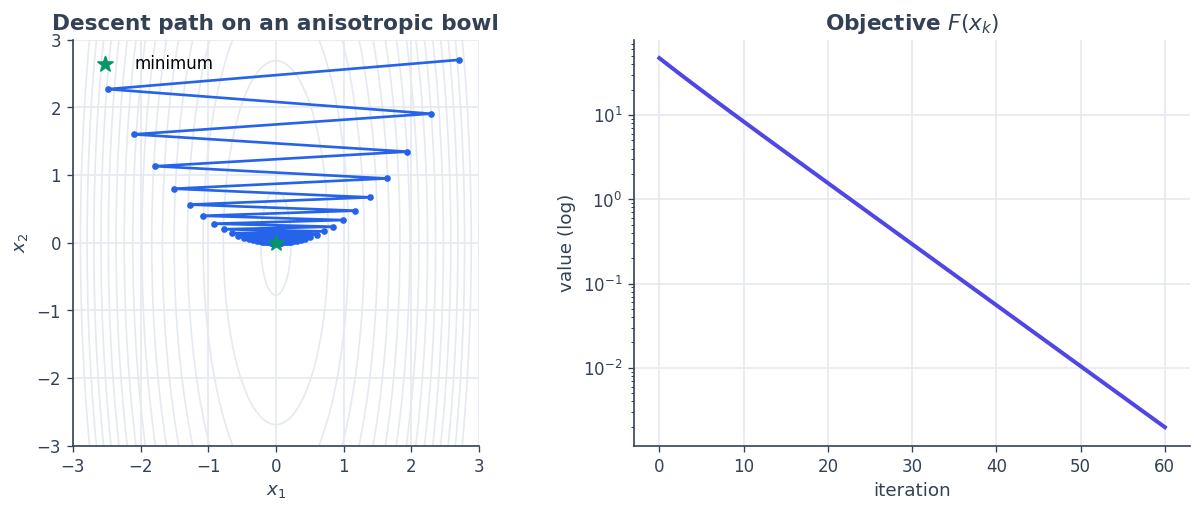

final point: [1.81398380e-02 7.72895765e-05]  final value: 0.0019743253289275227


In [5]:
def gradient_descent(F, x0, step, n_steps):
    x = x0
    xs, fs = [np.asarray(x).copy()], [float(F.value(x))]
    for _ in range(n_steps):
        x = x - step * F.grad(x)          # F.grad returns a domain element → valid step
        xs.append(np.asarray(x).copy()); fs.append(float(F.value(x)))
    return np.array(xs), np.array(fs)

H = np.array([[12.0, 0.0], [0.0, 1.0]])
bowl = QuadraticBowl(H, X2)
path, vals = gradient_descent(bowl, ctx.asarray([2.7, 2.7]), step=0.16, n_steps=60)

# contour field (F is just 0.5 xᵀHx, evaluated on a grid)
g = np.linspace(-3, 3, 240); GX, GY = np.meshgrid(g, g)
Z = 0.5 * (H[0, 0] * GX**2 + H[1, 1] * GY**2)

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.4))
axes[0].contour(GX, GY, Z, levels=np.linspace(0.3, 50, 16), colors=GRID, linewidths=1)
axes[0].plot(path[:, 0], path[:, 1], color=BLUE, marker="o", ms=3, lw=1.6)
axes[0].scatter([0], [0], color=GREEN, s=90, marker="*", zorder=6, label="minimum")
axes[0].set_aspect("equal"); axes[0].set_title("Descent path on an anisotropic bowl")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$"); axes[0].legend()

axes[1].semilogy(vals, color=INDIGO)
axes[1].set_title("Objective $F(x_k)$"); axes[1].set_xlabel("iteration")
axes[1].set_ylabel("value (log)")
plt.tight_layout(); plt.show()
print("final point:", path[-1], " final value:", vals[-1])

The path zig-zags: a single Euclidean step size cannot suit both the steep $x_1$ and the
shallow $x_2$ direction at once. That is a *geometry* problem — and SpaceCore lets us fix it
by changing the inner product.

## 4 · Gradients respect the geometry

Choosing the inner product is choosing a **preconditioner**. If we give the space the weighted
geometry $W = \mathrm{diag}(H)$, the *same* `QuadraticBowl` code now produces the gradient
$W^{-1} H x$ — because `grad` ends in `domain.riesz_inverse(...)`. Steepest descent in this
metric heads almost straight at the minimum. Nothing in the functional changed; only the
space did.

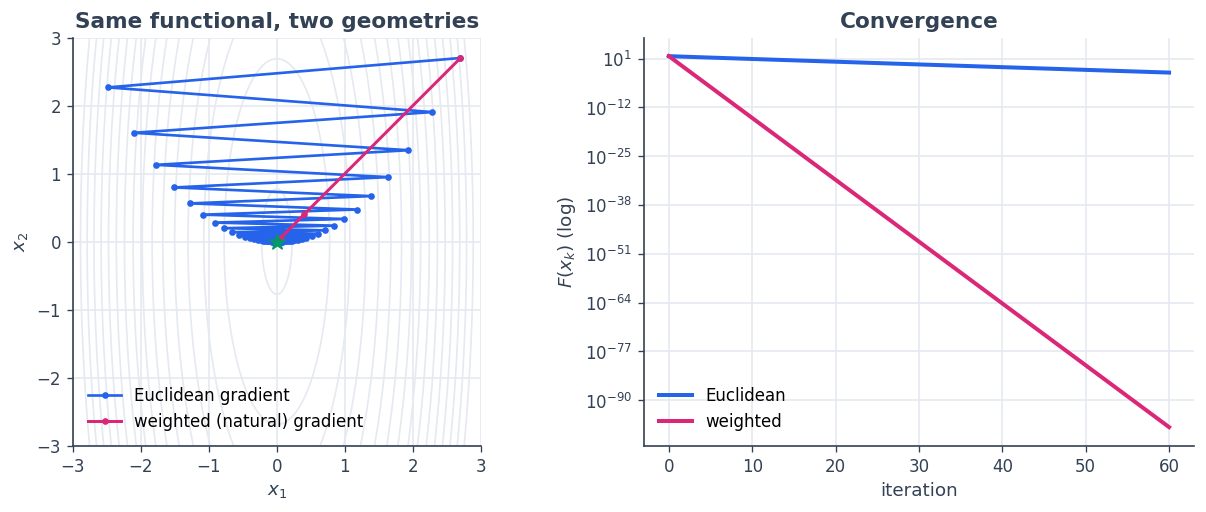

Euclidean final value: 0.0019743253289275227
weighted  final value: 6.406074302637951e-98


In [6]:
w = ctx.asarray(np.diag(H))                         # weights = (12, 1)
Xw = sc.DenseVectorSpace((2,), ctx, geometry=sc.WeightedInnerProduct(w))

bowl_e = QuadraticBowl(H, X2)                       # Euclidean space
bowl_w = QuadraticBowl(H, Xw)                       # weighted space — identical class!

path_e, val_e = gradient_descent(bowl_e, ctx.asarray([2.7, 2.7]), step=0.16, n_steps=60)
path_w, val_w = gradient_descent(bowl_w, ctx.asarray([2.7, 2.7]), step=0.85, n_steps=60)

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.4))
axes[0].contour(GX, GY, Z, levels=np.linspace(0.3, 50, 16), colors=GRID, linewidths=1)
axes[0].plot(path_e[:, 0], path_e[:, 1], color=BLUE, marker="o", ms=3, lw=1.6,
             label="Euclidean gradient")
axes[0].plot(path_w[:, 0], path_w[:, 1], color=PINK, marker="o", ms=3, lw=1.8,
             label="weighted (natural) gradient")
axes[0].scatter([0], [0], color=GREEN, s=90, marker="*", zorder=6)
axes[0].set_aspect("equal"); axes[0].set_title("Same functional, two geometries")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$"); axes[0].legend()

axes[1].semilogy(val_e, color=BLUE, label="Euclidean")
axes[1].semilogy(val_w, color=PINK, label="weighted")
axes[1].set_title("Convergence"); axes[1].set_xlabel("iteration")
axes[1].set_ylabel("$F(x_k)$ (log)"); axes[1].legend()
plt.tight_layout(); plt.show()
print("Euclidean final value:", val_e[-1])
print("weighted  final value:", val_w[-1])

The pink path — steepest descent under the metric matched to the problem — converges orders
of magnitude faster than the blue Euclidean path, with no change to the objective. This is the
seed of **Riemannian / natural-gradient** optimisation, which [tutorial 7](07_manifold_descent.ipynb)
develops on a curved manifold.

## Recap

* A **`Functional`** is a scalar map whose `grad(x)` is a *domain element*, so
  `x - η·grad` is a valid step.
* Build them with `InnerProductFunctional` / `LinOpQuadraticForm`, or **subclass
  `Functional`** and implement `value` (+ optionally `grad`).
* When you write `grad` by hand, finish with `domain.riesz_inverse(coord_grad)` so it is
  correct in any geometry.
* Choosing the inner product preconditions descent — the same code converges far faster under
  a fitted metric.

**Next:** [4 · Tree spaces](04_tree_spaces.ipynb) — structured elements and block operators.